# Bucket Boundary Analysis

**Original Design**: ATM/OTM5/OTM10 × 30/60/90 DTE (fixed values)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')

# Load cleaned options data
PROCESSED = Path('../data/clean/options')
options = pd.read_parquet(PROCESSED / 'ALL_options_clean.parquet')

# Filter to calls only
calls = options[options['call_put'] == 'call'].copy()

# Calculate DTE
calls['dte'] = (calls['expiration'] - calls['trade_date']).dt.days

print(f"Total call contracts: {len(calls):,}")

Total call contracts: 1,063,541


## 1. Moneyness Bucket Analysis (Using Delta)

In [3]:
# Filter to reasonable delta range for covered calls
calls_filtered = calls[(calls['delta'] >= 0.10) & (calls['delta'] <= 0.70)].copy()

print(f"Contracts in delta range 0.10-0.70: {len(calls_filtered):,}")

# Calculate percentiles
delta_percentiles = calls_filtered['delta'].quantile([0.25, 0.33, 0.50, 0.67, 0.75])
print(f"\nDelta Percentiles:")
print(delta_percentiles)

Contracts in delta range 0.10-0.70: 318,714

Delta Percentiles:
0.25    0.232492
0.33    0.281590
0.50    0.392210
0.67    0.502840
0.75    0.552980
Name: delta, dtype: float64


In [4]:
# Define moneyness buckets based on delta
print("  OTM10 (Far OTM):    delta 0.15 - 0.30")
print("  OTM5 (Near OTM):    delta 0.30 - 0.45")
print("  ATM (At-the-money): delta 0.45 - 0.60")

def assign_moneyness_bucket(delta):
    if 0.15 <= delta < 0.30:
        return 'OTM10'
    elif 0.30 <= delta < 0.45:
        return 'OTM5'
    elif 0.45 <= delta <= 0.60:
        return 'ATM'
    else:
        return 'OUT_OF_RANGE'

calls_filtered['moneyness_bucket'] = calls_filtered['delta'].apply(assign_moneyness_bucket)

print("\nContracts per Moneyness Bucket:")
print(calls_filtered['moneyness_bucket'].value_counts())

  OTM10 (Far OTM):    delta 0.15 - 0.30
  OTM5 (Near OTM):    delta 0.30 - 0.45
  ATM (At-the-money): delta 0.45 - 0.60

Contracts per Moneyness Bucket:
moneyness_bucket
OUT_OF_RANGE    88256
OTM10           81004
ATM             76376
OTM5            73078
Name: count, dtype: int64


In [5]:
# Moneyness bucket by ticker
print("Contracts per Moneyness Bucket by Ticker:")
moneyness_by_ticker = calls_filtered.groupby(['symbol', 'moneyness_bucket']).size().unstack(fill_value=0)
moneyness_by_ticker

Contracts per Moneyness Bucket by Ticker:


moneyness_bucket,ATM,OTM10,OTM5,OUT_OF_RANGE
symbol,,,,
AAPL,8055,10320,8300,10534
ADMA,370,307,358,285
AMZN,20942,18502,17793,22770
AXON,1639,1421,1509,1706
GOOG,16540,15992,14915,18507
META,4659,6696,5265,6069
MSFT,7122,8913,7344,8935
NTRA,702,886,770,748
NVDA,12181,13437,12544,14064


## 2. Maturity Bucket Analysis (Using DTE)

In [6]:
# Filter to reasonable DTE range
calls_dte = calls[(calls['dte'] >= 7) & (calls['dte'] <= 150)].copy()

print(f"Contracts in DTE range 7-150: {len(calls_dte):,}")

# Calculate percentiles
dte_percentiles = calls_dte['dte'].quantile([0.25, 0.33, 0.50, 0.67, 0.75])
print(f"\nDTE Percentiles:")
print(dte_percentiles)

Contracts in DTE range 7-150: 600,924

DTE Percentiles:
0.25    18.0
0.33    23.0
0.50    37.0
0.67    49.0
0.75    77.0
Name: dte, dtype: float64


In [7]:
# Define maturity buckets based on DTE
print("  DTE30 (Short):  7 - 37 days")
print("  DTE60 (Medium): 38 - 75 days")
print("  DTE90 (Long):   76 - 120 days")

def assign_maturity_bucket(dte):
    if 7 <= dte <= 37:
        return 'DTE30'
    elif 38 <= dte <= 75:
        return 'DTE60'
    elif 76 <= dte <= 120:
        return 'DTE90'
    else:
        return 'OUT_OF_RANGE'

calls_dte['maturity_bucket'] = calls_dte['dte'].apply(assign_maturity_bucket)

print("\nContracts per Maturity Bucket:")
print(calls_dte['maturity_bucket'].value_counts())

  DTE30 (Short):  7 - 37 days
  DTE60 (Medium): 38 - 75 days
  DTE90 (Long):   76 - 120 days

Contracts per Maturity Bucket:
maturity_bucket
DTE30           305039
DTE60           138712
DTE90           107206
OUT_OF_RANGE     49967
Name: count, dtype: int64


In [8]:
# Maturity bucket by ticker
print("Contracts per Maturity Bucket by Ticker:")
maturity_by_ticker = calls_dte.groupby(['symbol', 'maturity_bucket']).size().unstack(fill_value=0)
maturity_by_ticker

Contracts per Maturity Bucket by Ticker:


maturity_bucket,DTE30,DTE60,DTE90,OUT_OF_RANGE
symbol,,,,
AAPL,38070,19847,18193,7677
ADMA,630,730,553,265
AMZN,80031,33597,25146,11908
AXON,2543,2997,2457,1267
GOOG,68738,30319,20912,9307
META,17504,8887,7783,4066
MSFT,31745,13673,11307,5353
NTRA,1792,2144,1448,777
NVDA,44015,20560,16762,7959


## 3. Combined 9-Bucket Analysis

In [9]:
# Filter to both ranges
calls_9bucket = calls[
    (calls['delta'] >= 0.15) & (calls['delta'] <= 0.60) &
    (calls['dte'] >= 7) & (calls['dte'] <= 120)
].copy()

calls_9bucket['moneyness_bucket'] = calls_9bucket['delta'].apply(assign_moneyness_bucket)
calls_9bucket['maturity_bucket'] = calls_9bucket['dte'].apply(assign_maturity_bucket)

# Remove out of range
calls_9bucket = calls_9bucket[
    (calls_9bucket['moneyness_bucket'] != 'OUT_OF_RANGE') &
    (calls_9bucket['maturity_bucket'] != 'OUT_OF_RANGE')
]

# Create combined bucket
calls_9bucket['bucket'] = calls_9bucket['moneyness_bucket'] + '_' + calls_9bucket['maturity_bucket']

print(f"Total contracts in 9 buckets: {len(calls_9bucket):,}")
print(f"Percentage of all calls: {len(calls_9bucket) / len(calls) * 100:.1f}%")

Total contracts in 9 buckets: 96,427
Percentage of all calls: 9.1%


In [10]:
# Contracts per 9-bucket
print("Contracts per 9-Bucket:")
bucket_counts = calls_9bucket['bucket'].value_counts().sort_index()
print(bucket_counts)

Contracts per 9-Bucket:
bucket
ATM_DTE30      16341
ATM_DTE60       8684
ATM_DTE90       6375
OTM10_DTE30    18262
OTM10_DTE60     9089
OTM10_DTE90     7488
OTM5_DTE30     15783
OTM5_DTE60      8246
OTM5_DTE90      6159
Name: count, dtype: int64


In [11]:
# Bucket count matrix
bucket_matrix = calls_9bucket.groupby(['moneyness_bucket', 'maturity_bucket']).size().unstack(fill_value=0)
bucket_matrix = bucket_matrix.reindex(index=['ATM', 'OTM5', 'OTM10'], columns=['DTE30', 'DTE60', 'DTE90'])

print("Bucket Count Matrix:")
bucket_matrix

Bucket Count Matrix:


maturity_bucket,DTE30,DTE60,DTE90
moneyness_bucket,,,
ATM,16341,8684,6375
OTM5,15783,8246,6159
OTM10,18262,9089,7488


## 4. Visualizations

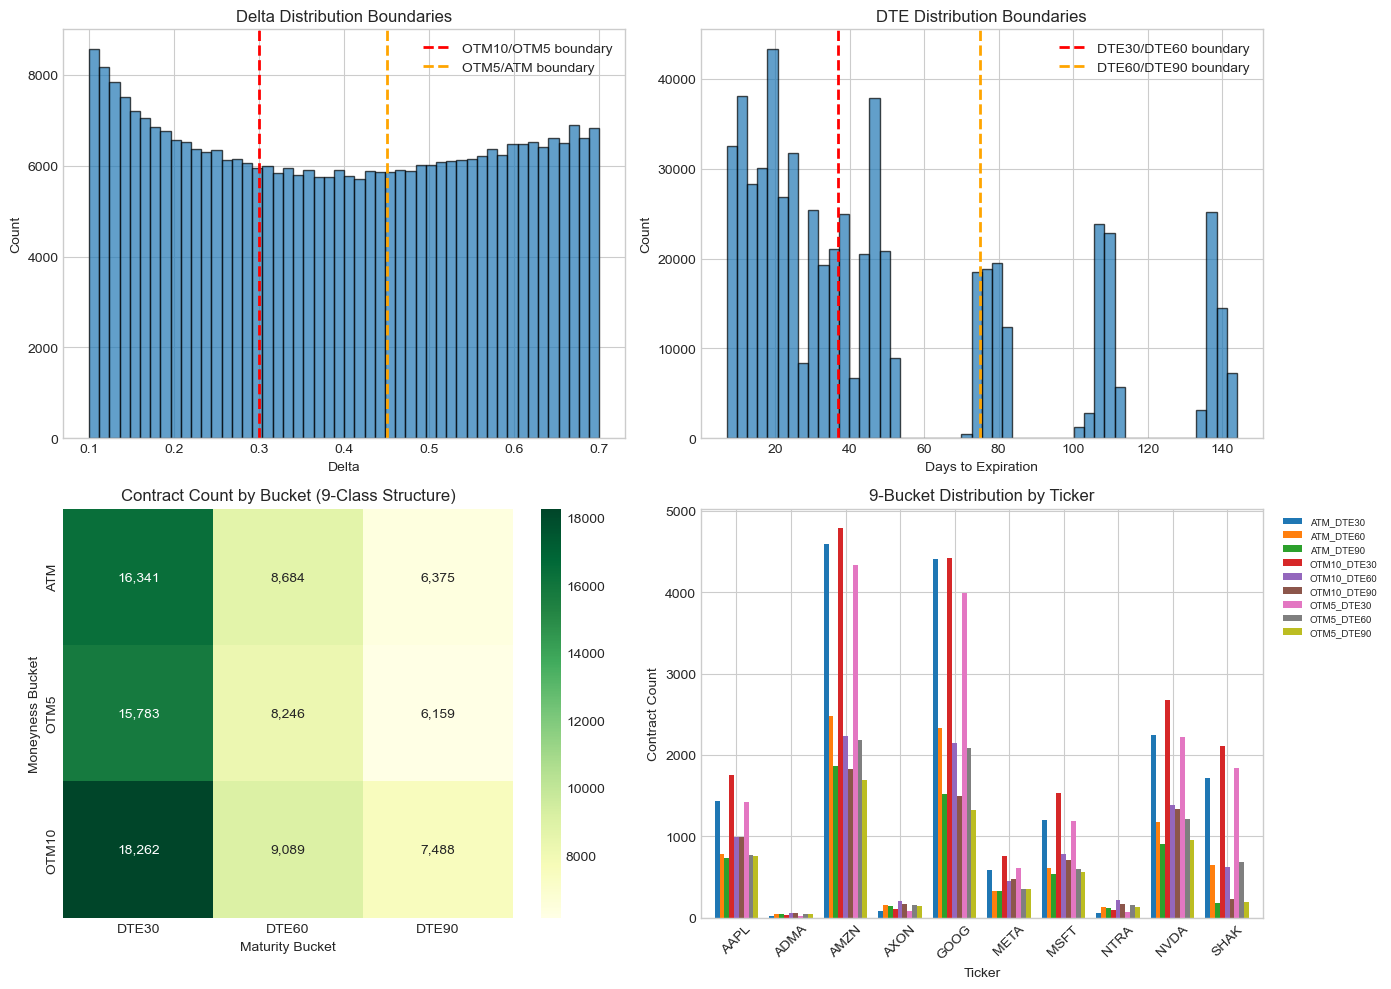

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delta distribution with bucket boundaries
ax1 = axes[0, 0]
calls_filtered['delta'].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7)
ax1.axvline(x=0.30, color='red', linestyle='--', linewidth=2, label='OTM10/OTM5 boundary')
ax1.axvline(x=0.45, color='orange', linestyle='--', linewidth=2, label='OTM5/ATM boundary')
ax1.set_xlabel('Delta')
ax1.set_ylabel('Count')
ax1.set_title('Delta Distribution Boundaries')
ax1.legend()

# DTE distribution with bucket boundaries
ax2 = axes[0, 1]
calls_dte[calls_dte['dte'] <= 150]['dte'].hist(bins=50, ax=ax2, edgecolor='black', alpha=0.7)
ax2.axvline(x=37, color='red', linestyle='--', linewidth=2, label='DTE30/DTE60 boundary')
ax2.axvline(x=75, color='orange', linestyle='--', linewidth=2, label='DTE60/DTE90 boundary')
ax2.set_xlabel('Days to Expiration')
ax2.set_ylabel('Count')
ax2.set_title('DTE Distribution Boundaries')
ax2.legend()

# Bucket count heatmap
ax3 = axes[1, 0]
sns.heatmap(bucket_matrix, annot=True, fmt=',', cmap='YlGn', ax=ax3)
ax3.set_title('Contract Count by Bucket (9-Class Structure)')
ax3.set_xlabel('Maturity Bucket')
ax3.set_ylabel('Moneyness Bucket')

# Bucket distribution by ticker
ax4 = axes[1, 1]
ticker_bucket = calls_9bucket.groupby(['symbol', 'bucket']).size().unstack(fill_value=0)
ticker_bucket.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_xlabel('Ticker')
ax4.set_ylabel('Contract Count')
ax4.set_title('9-Bucket Distribution by Ticker')
ax4.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../eda_plots/bucket_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Liquidity Check by Ticker

In [15]:
min_contracts_per_bucket = 100

ticker_bucket_counts = calls_9bucket.groupby(['symbol', 'bucket']).size().unstack(fill_value=0)

print("Contracts per Ticker per Bucket:")
display(ticker_bucket_counts)

print(f"\nTickers with <{min_contracts_per_bucket} contracts in any bucket:")
for ticker in ticker_bucket_counts.index:
    min_count = ticker_bucket_counts.loc[ticker].min()
    min_bucket = ticker_bucket_counts.loc[ticker].idxmin()
    if min_count < min_contracts_per_bucket:
        print(f"  {ticker}: {min_bucket} has only {min_count} contracts")

Contracts per Ticker per Bucket:


bucket,ATM_DTE30,ATM_DTE60,ATM_DTE90,OTM10_DTE30,OTM10_DTE60,OTM10_DTE90,OTM5_DTE30,OTM5_DTE60,OTM5_DTE90
symbol,,,,,,,,,
AAPL,1433,780,731,1750,990,997,1425,770,758
ADMA,25,42,47,33,59,57,19,47,49
AMZN,4593,2479,1859,4789,2237,1830,4331,2190,1690
AXON,82,154,141,102,200,167,84,150,141
GOOG,4412,2326,1520,4418,2144,1502,3990,2085,1325
META,584,331,328,761,456,481,610,354,351
MSFT,1198,613,543,1530,778,707,1187,602,565
NTRA,58,135,118,99,218,171,71,153,129
NVDA,2240,1179,911,2674,1388,1341,2227,1210,961



Tickers with <100 contracts in any bucket:
  ADMA: OTM5_DTE30 has only 19 contracts
  AXON: ATM_DTE30 has only 82 contracts
  NTRA: ATM_DTE30 has only 58 contracts


In [16]:
# Recommendation
low_liquidity = ticker_bucket_counts.min(axis=1)
low_liquidity_tickers = low_liquidity[low_liquidity < min_contracts_per_bucket].index.tolist()

if low_liquidity_tickers:
    print(f" Finak stocks selection: {low_liquidity_tickers}")
else:
    print(" All tickers have sufficient liquidity in all buckets.")

 Finak stocks selection: ['ADMA', 'AXON', 'NTRA']


In [17]:

print(f"\nTotal contracts captured: {len(calls_9bucket):,}")
print(f"Percentage of all calls: {len(calls_9bucket) / len(calls) * 100:.1f}%")


Total contracts captured: 96,427
Percentage of all calls: 9.1%
